## Baseline Model

In this section, I build a simple baseline model that will be used as the first\
reference point for later comparison. The goal here is not to create the best model,\
but to build a basic benchmark.

This baseline also helps show where the model performs poorly. By looking at its errors,\
we can better understand what is missing and use those insights later in the EDA and feature\
engineering steps.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
DATA_CODE_DIR = Path().resolve().parent / "01_data"

if str(DATA_CODE_DIR) not in sys.path:
    sys.path.append(str(DATA_CODE_DIR))

from load_data import load_stock_data

In [3]:
df = load_stock_data()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (40351, 8)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL


Our data

In [4]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

print("\nTickers:")
print(df["Ticker"].unique())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40351 entries, 0 to 40350
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       40351 non-null  datetime64[ns]
 1   Open       40351 non-null  float64       
 2   High       40351 non-null  float64       
 3   Low        40351 non-null  float64       
 4   Close      40351 non-null  float64       
 5   Adj Close  40351 non-null  float64       
 6   Volume     40351 non-null  int64         
 7   Ticker     40351 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 2.5+ MB
None

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Tickers:
['AAPL' 'AMZN' 'GOOGL' 'HD' 'JNJ' 'JPM' 'META' 'MSFT' 'PG' 'XOM']

Date range:
2010-01-04 00:00:00 to 2026-04-15 00:00:00


In [5]:
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL


Data looks clean and tidy

In [6]:
df_model = df.copy()

# Daily return
df_model["Return_1d"] = df_model.groupby("Ticker")["Close"].pct_change(1)

# Lagged returns
df_model["Return_3d"] = df_model.groupby("Ticker")["Close"].pct_change(3)
df_model["Return_5d"] = df_model.groupby("Ticker")["Close"].pct_change(5)

# Rolling volatility
df_model["Volatility_5d"] = (
    df_model.groupby("Ticker")["Return_1d"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

# Volume change
df_model["Volume_Change_1d"] = df_model.groupby("Ticker")["Volume"].pct_change(1)

# Target = next-day close price
df_model["Target_Next_Close"] = df_model.groupby("Ticker")["Close"].shift(-1)

df_model.head(10)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Next_Close
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,7.656429
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL,0.001729,NaN,NaN,NaN,0.219098,7.534643
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL,-0.015906,NaN,NaN,NaN,-0.082646,7.520714
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016027,NaN,NaN,-0.135882,7.570714
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL,0.006648,-0.011195,NaN,NaN,-0.061871,7.503929
5,2010-01-11,7.600000,7.607143,7.444643,7.503929,6.295528,462229600,AAPL,-0.008821,-0.004076,-0.018223,0.008877,0.032660,7.418571
6,2010-01-12,7.471071,7.491786,7.372143,7.418571,6.223917,594459600,AAPL,-0.011375,-0.013582,-0.031066,0.008830,0.286070,7.523214
7,2010-01-13,7.423929,7.533214,7.289286,7.523214,6.311708,605892000,AAPL,0.014106,-0.006274,-0.001517,0.010647,0.019232,7.479643
8,2010-01-14,7.503929,7.516429,7.465000,7.479643,6.275152,432894000,AAPL,-0.005792,-0.003236,-0.005461,0.010937,-0.285526,7.354643
9,2010-01-15,7.533214,7.557143,7.352500,7.354643,6.170284,594067600,AAPL,-0.016712,-0.008617,-0.028540,0.011784,0.372317,7.680000


At this stage, we create baseline features from historical price and volume data.
The prediction target is the next-day closing price, so the model is aligned with
price forecasting requirements.


In [7]:
feature_cols = [
    "Close",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volume_Change_1d"
]

target_col = "Target_Next_Close"

print(df_model[feature_cols + [target_col]].isna().sum())


Close                 0
Return_1d            10
Return_3d            30
Return_5d            50
Volatility_5d        50
Volume_Change_1d     10
Target_Next_Close    10
dtype: int64


At this stage, we check how many missing values appear in the baseline features.\
These missing values are expected because of lagged returns, rolling volatility\
and the next-day target

In [8]:
df_model = df_model.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

print(df_model.shape)
df_model.head()

(40291, 14)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Next_Close
0,2010-01-11,7.600000,7.607143,7.444643,7.503929,6.295528,462229600,AAPL,-0.008821,-0.004076,-0.018223,0.008877,0.032660,7.418571
1,2010-01-12,7.471071,7.491786,7.372143,7.418571,6.223917,594459600,AAPL,-0.011375,-0.013582,-0.031066,0.008830,0.286070,7.523214
2,2010-01-13,7.423929,7.533214,7.289286,7.523214,6.311708,605892000,AAPL,0.014106,-0.006274,-0.001517,0.010647,0.019232,7.479643
3,2010-01-14,7.503929,7.516429,7.465000,7.479643,6.275152,432894000,AAPL,-0.005792,-0.003236,-0.005461,0.010937,-0.285526,7.354643
4,2010-01-15,7.533214,7.557143,7.352500,7.354643,6.170284,594067600,AAPL,-0.016712,-0.008617,-0.028540,0.011784,0.372317,7.680000


In [9]:
df_model[target_col].describe()

count    40291.000000
mean       123.345038
std        107.019069
min          5.430500
25%         52.597250
50%         93.320000
75%        158.095245
max        790.000000
Name: Target_Next_Close, dtype: float64

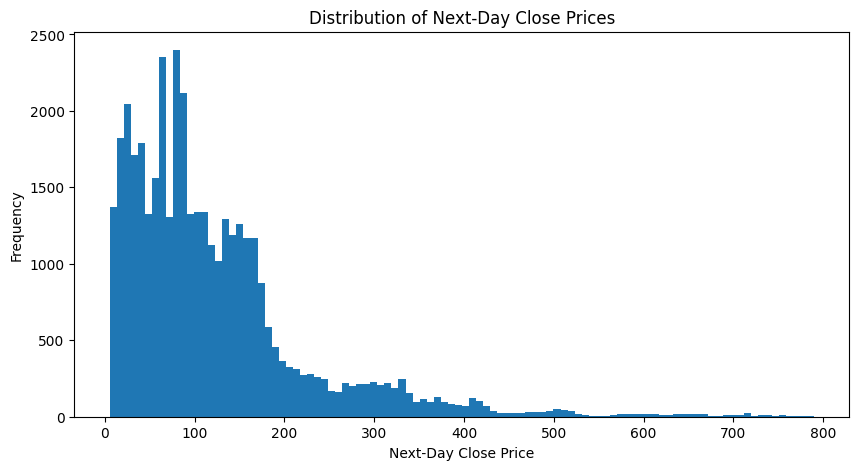

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df_model[target_col], bins=100)
plt.title("Distribution of Next-Day Close Prices")
plt.xlabel("Next-Day Close Price")
plt.ylabel("Frequency")
plt.show()


#### Some take-away
The results show that most returns are concentrated close to zero, while a few large\
positive and negative moves create long tails, which is expected in financial data.

In [11]:
split_date = df_model["Date"].quantile(0.80)

train_df = df_model[df_model["Date"] <= split_date].copy()
test_df = df_model[df_model["Date"] > split_date].copy()

print("Split date:", split_date)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Split date: 2023-01-26 00:00:00
Train shape: (32241, 14)
Test shape: (8050, 14)


In [12]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [13]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [14]:
train_preds = baseline_model.predict(X_train)
test_preds = baseline_model.predict(X_test)

In [15]:
def evaluate_regression(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {dataset_name} ---")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R?: {r2:.6f}")
    print()


At this stage, we define evaluation functions to measure how well the regression
model predicts next-day prices.


In [16]:
evaluate_regression(y_train, train_preds, "Train")
evaluate_regression(y_test, test_preds, "Test")

--- Train ---
MAE: 1.063065
RMSE: 2.061524
R?: 0.999081

--- Test ---
MAE: 2.912196
RMSE: 5.097510
R?: 0.998640



Evaluate the baseline model on both the training and test sets using MAE, RMSE,
and R2. These metrics show how closely the predictions follow actual next-day prices.


In [17]:
test_results = test_df.copy()
test_results["Predicted_Next_Close"] = test_preds
test_results["Residual"] = test_results[target_col] - test_results["Predicted_Next_Close"]
test_results["Absolute_Error"] = np.abs(test_results["Residual"])

test_results.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volume_Change_1d,Target_Next_Close,Predicted_Next_Close,Residual,Absolute_Error
3284,2023-01-27,143.160004,147.229996,143.080002,145.929993,143.626785,70555800,AAPL,0.013684,0.023855,0.058461,0.010298,0.304051,143.000000,145.837934,-2.837934,2.837934
3285,2023-01-30,144.960007,145.550003,142.850006,143.000000,140.743027,64015300,AAPL,-0.020078,0.008036,0.013394,0.014958,-0.092700,144.289993,143.147083,1.142910,1.142910
3286,2023-01-31,142.699997,144.339996,142.279999,144.289993,142.012665,65874500,AAPL,0.009021,0.002292,0.012348,0.014837,0.029043,145.429993,144.258323,1.171670,1.171670
3287,2023-02-01,143.970001,146.610001,141.320007,145.429993,143.134674,77663600,AAPL,0.007901,-0.003426,0.025166,0.014361,0.178963,150.820007,145.381174,5.438834,5.438834
3288,2023-02-02,148.899994,151.179993,148.169998,150.820007,148.439606,118339000,AAPL,0.037063,0.054685,0.047652,0.020340,0.523738,154.500000,150.574556,3.925444,3.925444


This table shows actual next-day prices, predicted prices, residuals, and absolute
errors so we can inspect where the baseline model misses more.


In [18]:
stock_metrics = []

for ticker in test_results["Ticker"].unique():
    temp = test_results[test_results["Ticker"] == ticker]

    mae = mean_absolute_error(temp[target_col], temp["Predicted_Next_Close"])
    rmse = np.sqrt(mean_squared_error(temp[target_col], temp["Predicted_Next_Close"]))
    r2 = r2_score(temp[target_col], temp["Predicted_Next_Close"])

    stock_metrics.append({
        "Ticker": ticker,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

stock_metrics_df = pd.DataFrame(stock_metrics).sort_values("RMSE")
stock_metrics_df


,Ticker,MAE,RMSE,R2
8,PG,1.224238,1.669444,0.970555
9,XOM,1.291665,1.729128,0.980411
4,JNJ,1.290064,1.815707,0.994561
0,AAPL,2.294178,3.354042,0.990652
5,JPM,2.256481,3.399223,0.997009
2,GOOGL,2.434836,3.487875,0.996920
1,AMZN,2.605929,3.650590,0.992651
3,HD,3.720367,4.918796,0.983068
7,MSFT,4.252586,6.001752,0.992231
6,META,7.751620,11.927296,0.995153


**Evaluation**:\
The results show that performance is fairly similar overall, with some stocks\
being slightly easier to predict than others.

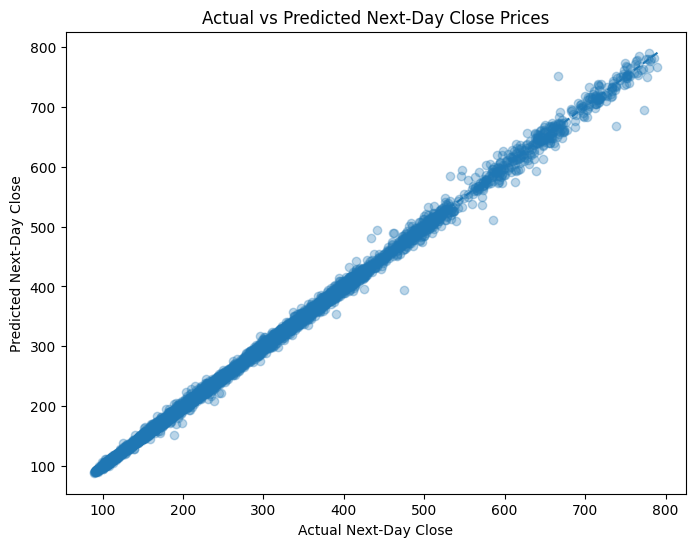

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(test_results[target_col], test_results["Predicted_Next_Close"], alpha=0.3)

min_val = min(test_results[target_col].min(), test_results["Predicted_Next_Close"].min())
max_val = max(test_results[target_col].max(), test_results["Predicted_Next_Close"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Predicted Next-Day Close Prices")
plt.xlabel("Actual Next-Day Close")
plt.ylabel("Predicted Next-Day Close")
plt.show()


The baseline model captures general price levels but still misses part of the daily
variation. Larger errors are visible on more volatile days.


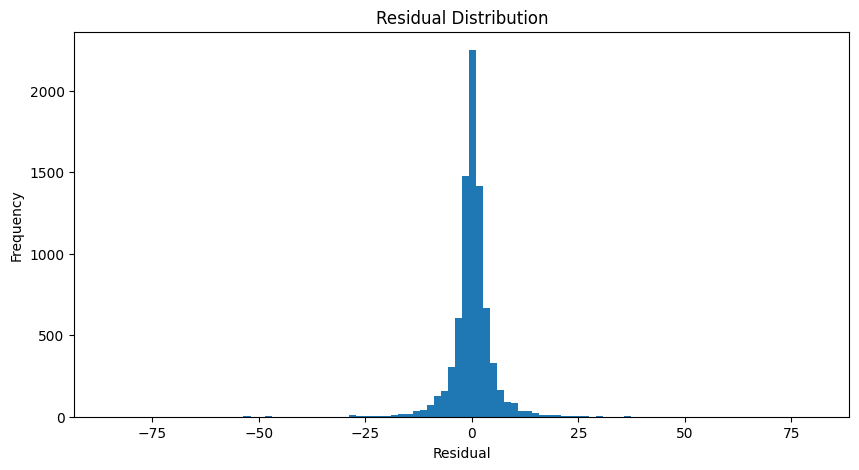

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(test_results["Residual"], bins=100)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

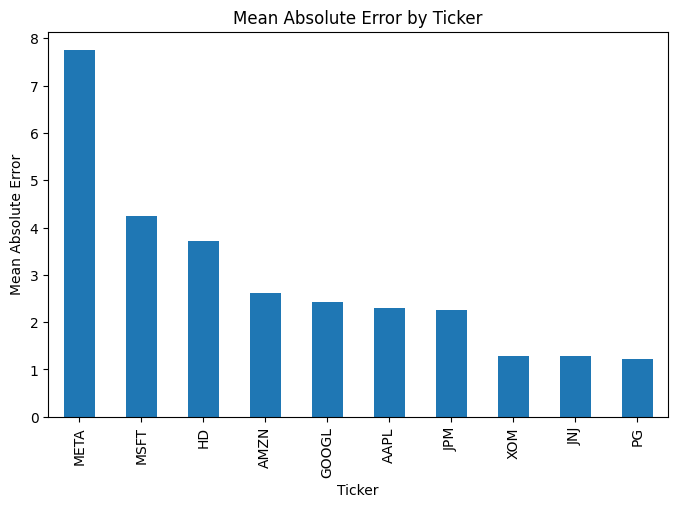

Ticker
META     7.751620
MSFT     4.252586
HD       3.720367
AMZN     2.605929
GOOGL    2.434836
AAPL     2.294178
JPM      2.256481
XOM      1.291665
JNJ      1.290064
PG       1.224238
Name: Absolute_Error, dtype: float64

In [21]:
error_by_ticker = (
    test_results.groupby("Ticker")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
error_by_ticker.plot(kind="bar")
plt.title("Mean Absolute Error by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Mean Absolute Error")
plt.show()

error_by_ticker

Okkkke,sooooo we examine the residuals and mean absolute error by ticker to better\
understand where the baseline model makes mistakes.\
What we got: The errors are centered close to zero overall, but ticker-level performance\
is uneven and some stocks show clearly larger prediction errors than others.

In [22]:
test_results.sort_values("Absolute_Error", ascending=False)[
    ["Date", "Ticker", target_col, "Predicted_Next_Close", "Residual", "Absolute_Error"]
].head(10)


,Date,Ticker,Target_Next_Close,Predicted_Next_Close,Residual,Absolute_Error
27910,2025-10-29,META,666.469971,751.478199,-85.008228,85.008228
27473,2024-02-01,META,474.989990,394.630528,80.359463,80.359463
27846,2025-07-30,META,773.440002,695.089925,78.350078,78.350078
27769,2025-04-08,META,585.770020,510.471784,75.298236,75.298236
27971,2026-01-28,META,738.309998,668.499474,69.810524,69.810524
27765,2025-04-02,META,531.619995,583.891828,-52.271833,52.271833
27530,2024-04-24,META,441.380005,493.355287,-51.975282,51.975282
32060,2026-01-28,MSFT,433.500000,481.497983,-47.997983,47.997983
28010,2026-03-25,META,547.539978,594.802103,-47.262125,47.262125
27791,2025-05-09,META,639.429993,592.494029,46.935963,46.935963


The biggest misses are concentrated in high-volatility days, which suggests the
baseline setup is still too simple for sudden price moves.


In [23]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_model.coef_
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,Close,0.999741
2,Return_3d,0.598899
5,Volume_Change_1d,-0.064480
3,Return_5d,-0.913993
4,Volatility_5d,-3.083790
1,Return_1d,-5.789106


Baseline model coefficients show how each feature affects predicted next-day close
price. The current close level has the largest direct influence, while return and
volatility features add smaller adjustments.


### Baseline Takeaways

- The baseline model can follow broad price levels but still has limited precision.
- Error size changes by ticker and by market regime.
- The largest errors appear on more volatile days.
- A stronger model should add richer features and nonlinear effects.
